In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/processed/neo_close_approaches_clean.csv')

In [3]:
df.head()

,des,orbit_id,jd,cd,dist,dist_min,dist_max,v_rel,v_inf,t_sigma_f,h,diameter,diameter_sigma,fullname,is_comet
0,509352,64,2.415024e+06,1900-01-04 22:25:00,0.009632,0.009625,0.009639,8.686710,8.654806,00:02,20.14,NaN,NaN,509352 (2007 AG),False
1,2014 SC324,57,2.415031e+06,1900-01-11 01:07:00,0.039964,0.039904,0.040025,10.652382,10.646122,00:18,24.39,NaN,NaN,(2014 SC324),False
2,2012 UK171,54,2.415032e+06,1900-01-12 23:02:00,0.049706,0.049578,0.049834,7.153496,7.145999,00:05,24.46,NaN,NaN,(2012 UK171),False
3,2024 BA5,3,2.415045e+06,1900-01-25 06:22:00,0.026434,0.011310,0.198644,8.436204,8.424247,21:33,26.02,NaN,NaN,(2024 BA5),False
4,2024 BW1,6,2.415045e+06,1900-01-25 19:29:00,0.037979,0.010125,0.089436,6.339787,6.328711,4_11:16,25.12,NaN,NaN,(2024 BW1),False


In [4]:
df.shape

(51122, 15)

# Q1 - Is there a correlation between dist and v_rel? (do closer approaches tend to be faster or slower, or no relationship at all?)

In [5]:
df['dist'].corr(df['v_rel'])

np.float64(-0.007313688439749968)

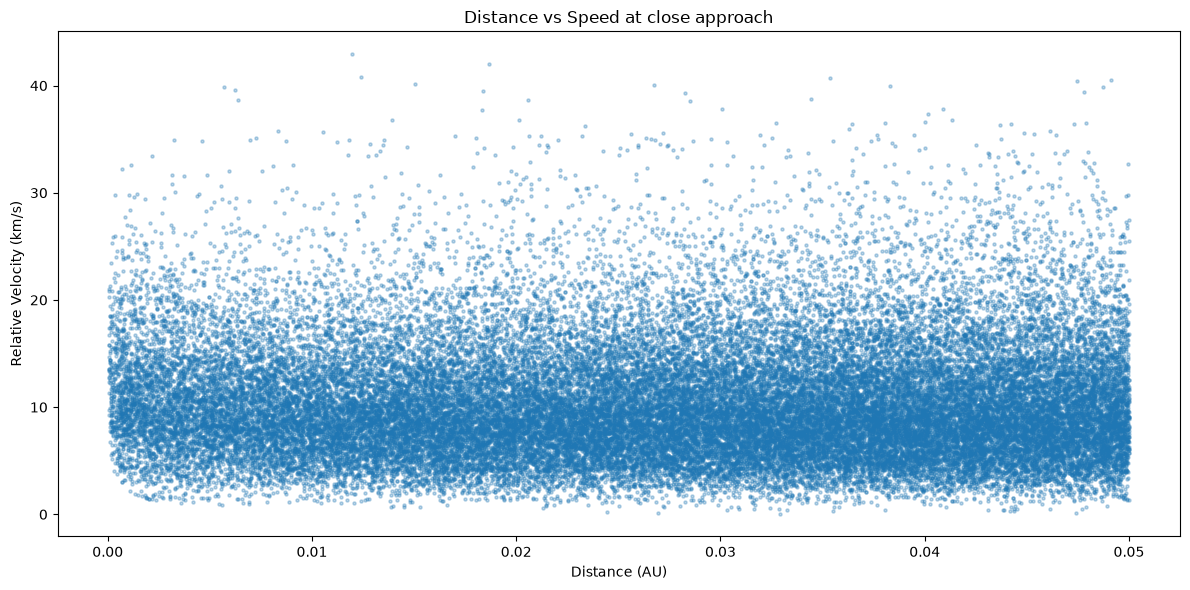

In [6]:
plt.figure(figsize=(12,6))

plt.scatter(df['dist'], df['v_rel'],  alpha=0.3, s=5)

plt.xlabel('Distance (AU)')
plt.ylabel('Relative Velocity (km/s)')
plt.title('Distance vs Speed at close approach')

plt.tight_layout()
plt.show()

### Q1: No meaningful correlation between distance and relative velocity (r ≈ -0.007). Close approach speed appears independent of how close the object gets — likely because velocity is driven by the asteroid's own orbital shape, not by the specific geometry of a given Earth encounter.

# Q2 - What does the distribution of dist look like — are most close approaches clustered near the 0.05 AU limit, or spread evenly, or clustered near zero?

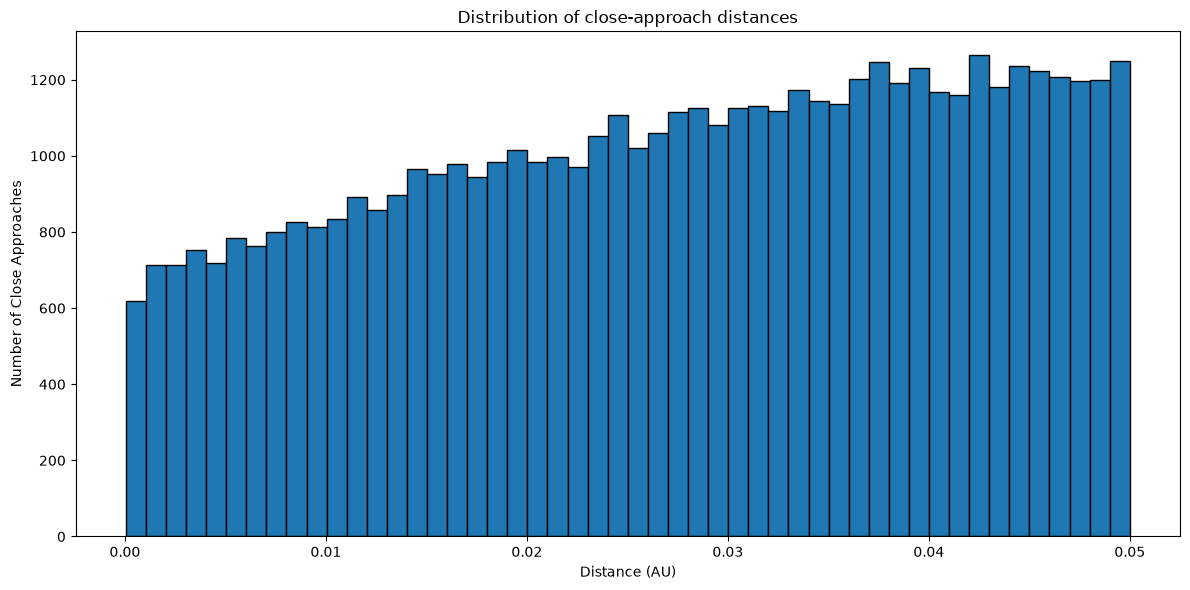

In [7]:
plt.figure(figsize=(12,6))

plt.hist(df['dist'], bins=50, edgecolor='black')

plt.xlabel('Distance (AU)')
plt.ylabel('Number of Close Approaches')
plt.title('Distribution of close-approach distances')

plt.tight_layout()
plt.show()

### Q2: Close-approach distances are not uniformly distributed — frequency increases roughly linearly (from ~620 to ~1,250 approaches) from near-zero out to the 0.05 AU limit. This matches expected geometry (more volume of space at larger distances = more objects passing through), not a real astronomical preference for farther approaches.

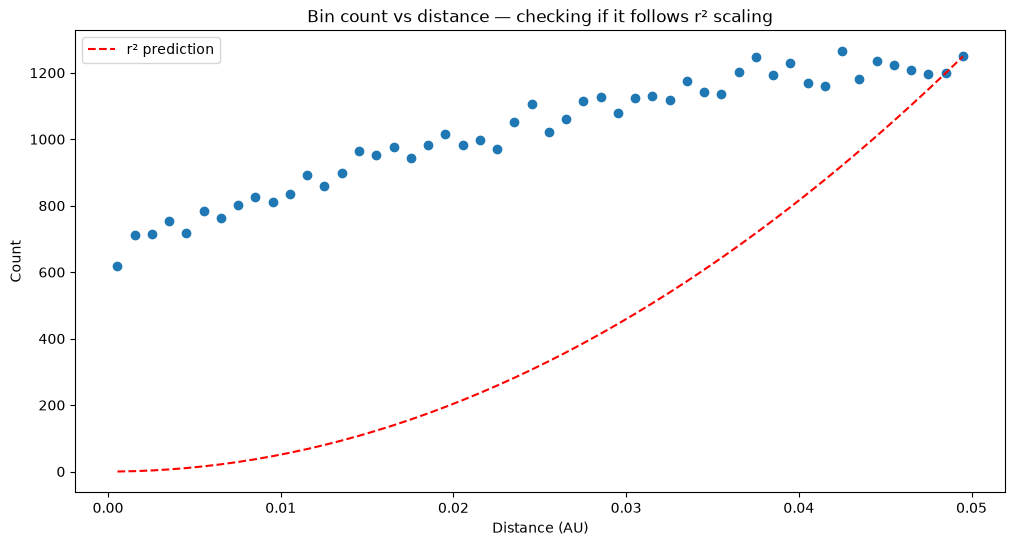

In [8]:
counts, bin_edges = np.histogram(df['dist'], bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(12,6))
plt.scatter(bin_centers, counts)
plt.xlabel('Distance (AU)')
plt.ylabel('Count')
plt.title('Bin count vs distance — checking if it follows r² scaling')

# overlay a fitted r^2 curve to compare
plt.plot(bin_centers, counts[-1] * (bin_centers/bin_centers[-1])**2, 
         color='red', linestyle='--', label='r² prediction')
plt.legend()
plt.show()

### Q2 (revised): Close-approach distances increase roughly linearly with distance, but this does NOT match a simple r²/geometric-volume explanation — the real data grows faster at small distances than pure geometry predicts. The cause is more likely detection/tracking bias (very close approaches get flagged and confirmed more reliably) than random spatial geometry. Needs more digging to fully explain, or should be stated as an open question rather than resolved.

# Q3 - How many objects have passed closer than the Moon's distance (~0.00257 AU)? Closer than geostationary satellites (~0.00017 AU)?

In [9]:
closer_than_moon = df[df['dist'] < 0.00257]
# gs stands for geostationary satellites
closer_than_gs = df[df['dist'] < 0.00017]

In [10]:
moon_pct = closer_than_moon.shape[0]/len(df) * 100
gs_pct = closer_than_gs.shape[0]/len(df) * 100

#### Percentage of the objects closer than moon

In [11]:
print(moon_pct)

3.346895661359102


#### Percentage of the objects closer than geostationary satellites

In [12]:
print(gs_pct)

0.10758577520441298


#### numbers of them
#### 1) objects closer than moon
#### 2) objects closer than geostationary satellites

In [13]:
closer_than_moon.shape[0]

1711

In [14]:
closer_than_gs.shape[0]

55

## Q3: How many close approaches happen within key distance thresholds?

We checked two reference distances: the Moon's average distance (~0.00257 AU) 
and geostationary satellite altitude (~0.00017 AU).

- **Closer than the Moon:** 1,711 objects (~3.35% of all 51,122 recorded close approaches)
- **Closer than geostationary satellites:** 55 objects (~0.11%)

Roughly 1 in 30 recorded close approaches came nearer than the Moon — a notable 
share, especially given the Q2 finding that closer approaches are, if anything, 
overrepresented relative to a pure geometric expectation. The geostationary 
threshold is a much rarer tier: only 55 objects out of the entire dataset (about 
1 in 930) have ever been recorded passing that close, making this a genuinely 
small, high-attention group worth examining individually.

In [15]:
closer_than_gs[['des', 'cd', 'dist', 'h', 'diameter']].sort_values('dist')

,des,cd,dist,h,diameter
31381,2025 UC11,2025-10-30 12:11:00,0.000044,34.060,NaN
23077,2020 VT4,2020-11-13 17:21:00,0.000045,28.610,NaN
31169,2025 TF,2025-10-01 00:49:00,0.000045,31.700,NaN
29792,2024 XA,2024-12-01 09:46:00,0.000052,31.640,NaN
28928,2024 LH1,2024-06-06 14:02:00,0.000054,30.790,NaN
29589,2024 UG9,2024-10-30 12:42:00,0.000059,32.610,NaN
22620,2020 QG,2020-08-16 04:09:00,0.000062,29.900,NaN
24548,2021 UA1,2021-10-25 03:07:00,0.000063,31.840,NaN
30089,2025 BP6,2025-01-26 01:10:00,0.000065,31.820,NaN
26738,2023 BU,2023-01-27 00:29:00,0.000067,29.690,NaN


### Closest approaches (within geostationary satellite distance)

Examining the 55 objects that passed closer than geostationary satellites, 
sorted by distance:

- **Every object in this group has `diameter = NaN`** — none have a directly 
  measured size, consistent with the earlier finding that diameter data is 
  rare (~3% of the full dataset) and tends to be missing for small, recently 
  discovered objects.
- **`h` values range from ~27.9 to ~34.1**, placing every object at the small/
  faint end of the scale — these are very small asteroids, likely only a few 
  meters across, not major hazardous bodies.
- **No large object appears in this group.** This supports the earlier reasoning: 
  a genuinely large asteroid on a trajectory this close to Earth would almost 
  certainly already be a known, tracked object well before its closest approach, 
  rather than showing up unflagged in this list.
- **Detections skew toward recent years** (the majority are 2019 or later), 
  suggesting improving detection sensitivity for very small objects over time, 
  rather than these extremely close passes being a recent phenomenon in the 
  objects themselves.

# Q4 - What's the fastest and slowest relative velocity recorded, and what were the circumstances (close approach distance, date)?

In [16]:
slowest_approaches = df.sort_values('v_rel', axis=0, ascending=True)
fastest_approaches = df.sort_values('v_rel', axis=0, ascending=False)

In [17]:
slowest_approaches[['des', 'cd', 'dist', 'v_rel', 'h']].head()

,des,cd,dist,v_rel,h
37470,2023 HG11,2061-07-29 16:21:00,0.032892,0.073451,28.37
33100,2006 RH120,2028-08-18 04:47:00,0.026936,0.138271,29.50
49829,2024 GB15,2179-05-21 04:34:00,0.047423,0.168685,26.95
35158,2020 CD3,2044-03-20 10:43:00,0.024444,0.216288,31.74
7696,2012 TF79,1967-01-20 03:00:00,0.035501,0.275869,27.38


In [18]:
fastest_approaches[['des', 'cd', 'dist', 'v_rel', 'h']].head()

,des,cd,dist,v_rel,h
12276,1999 J6,1999-06-12 05:23:00,0.011956,42.918833,NaN
49806,466130,2179-03-23 03:19:00,0.018668,41.973911,18.25
45634,2020 CY1,2126-02-09 16:43:00,0.012396,40.757532,23.69
946,2012 MS4,1909-12-16 04:11:00,0.035347,40.672808,18.68
8995,2022 RX3,1975-10-10 13:16:00,0.049140,40.509275,17.70


#### Correlations

In [19]:
fastest_50 = df.sort_values('v_rel', ascending=False).head(50)
slowest_50 = df.sort_values('v_rel', ascending=True).head(50)

fastest_50['dist'].corr(fastest_50['v_rel'])

np.float64(-0.22476991137557442)

In [20]:
slowest_50['dist'].corr(slowest_50['v_rel'])

np.float64(-0.38176088848481654)

In [21]:
slowest_50['dist'].corr(slowest_50['v_rel'])

df['h'].corr(df['v_rel'])

np.float64(-0.40673670078667357)

## Q4: Fastest and slowest relative velocities

**Slowest recorded approaches:** ~0.07 to 0.28 km/s (distances 0.024–0.047 AU).
**Fastest recorded approaches:** ~40.5 to 42.9 km/s (distances 0.012–0.049 AU).

Initial inspection of the top/bottom 5 rows suggested no distance pattern, 
consistent with Q1. However, checking correlation within the top 50 fastest 
and bottom 50 slowest approaches shows a real, moderate negative relationship 
between distance and velocity in both groups (fastest 50: r = -0.22, slowest 
50: r = -0.38) — closer approaches tend to be faster, even though this 
relationship disappears when looking at the full dataset (Q1: r ≈ -0.007). 
This suggests the distance-velocity relationship may only emerge at the 
extremes, not across typical approaches — worth exploring further.

Also notable: `h` (size proxy) correlates with `v_rel` at r = -0.41 across the 
full dataset — since lower `h` means a larger object, this indicates **larger 
objects tend to approach faster, and smaller objects tend to approach slower**. 
This is a meaningful lead for the upcoming size-related questions.

#### Since there is interesting correlation, plot it too

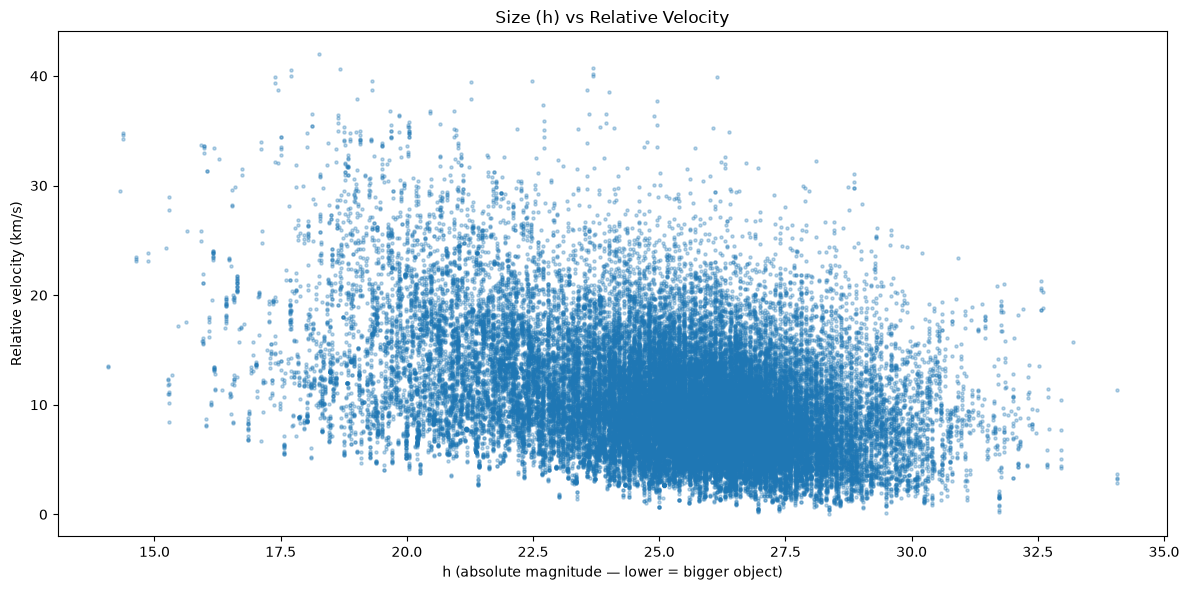

In [22]:
plt.figure(figsize=(12,6))

plt.scatter(df['h'], df['v_rel'], alpha=0.3, s=5)
plt.xlabel('h (absolute magnitude — lower = bigger object)')
plt.ylabel('Relative velocity (km/s)')
plt.title('Size (h) vs Relative Velocity')

plt.tight_layout()
plt.show()

### h vs v_rel — visual confirmation

The scatter plot confirms the r = -0.41 correlation: there's a visible downward 
trend, with larger objects (lower h, left side) reaching higher velocities 
(up to 40+ km/s) and smaller objects (higher h, right side) clustering mostly 
under 15-20 km/s.

The relationship isn't a tight line — it's more of a fan shape. Large objects 
show a wide spread of possible speeds (both slow and very fast), while small 
objects are heavily concentrated at lower speeds with few fast outliers. This 
suggests being large doesn't guarantee high speed, but being small does seem 
to make a very fast approach less likely.

### Caveat on the h vs v_rel relationship

This pattern is more likely a detection-bias artifact than a real physical 
relationship. Small, fast-moving objects are the hardest category to detect — 
they're only bright enough to spot when very close to Earth, and high speed 
shortens the window available to catch and confirm them. Large objects don't 
suffer this limitation, since they're detectable from farther away regardless 
of speed. So the dataset likely underrepresents fast-moving small asteroids, 
rather than showing that small asteroids are actually slower on average.

# Q5 - Does v_rel vary by anything else measurable — e.g., is there a typical speed range, or huge spread?

In [23]:
df['v_rel'].describe()

count    51122.000000
mean        10.301089
std          5.271150
min          0.073451
25%          6.574564
50%          9.313345
75%         12.999827
max         42.918833
Name: v_rel, dtype: float64

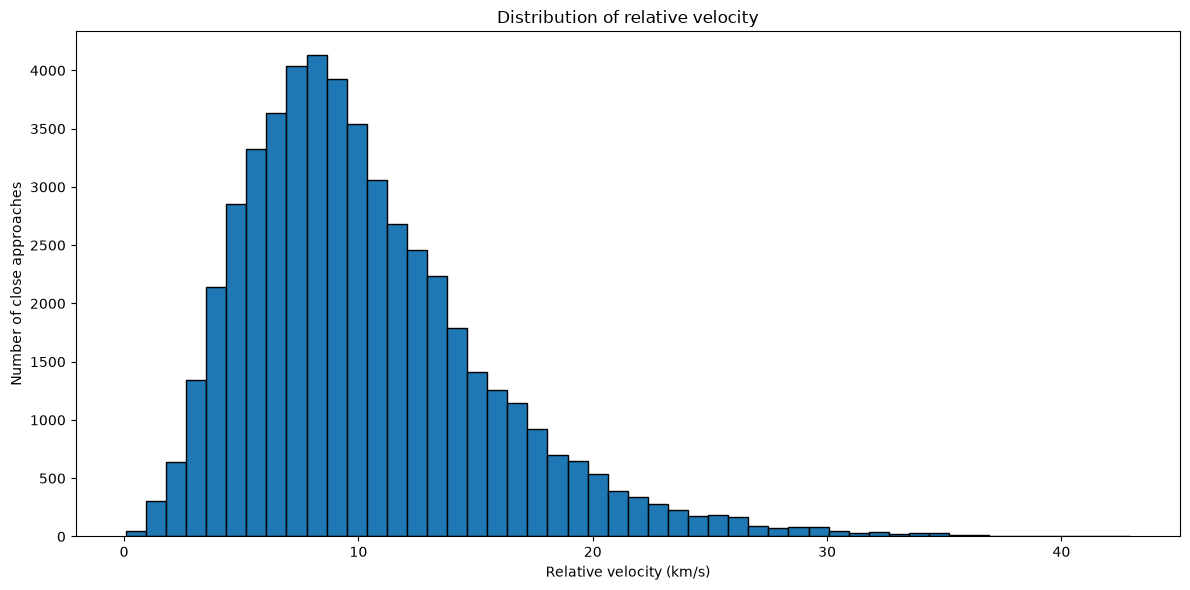

In [24]:
plt.figure(figsize=(12,6))

plt.hist(df['v_rel'], bins=50, edgecolor='black')
plt.xlabel('Relative velocity (km/s)')
plt.ylabel('Number of close approaches')
plt.title('Distribution of relative velocity')

plt.tight_layout()
plt.show()

## Q5: Does v_rel have a typical range, or huge spread?
Summary statistics (n=51,122): mean = 10.30 km/s, median = 9.31 km/s, 
std = 5.27 km/s, range 0.07-42.92 km/s. Middle 50% of values (25th-75th 
percentile) fall between 6.57 and 13.00 km/s.

The distribution is right-skewed: most close approaches cluster around 
5-15 km/s (peak near 8-10 km/s), but a long tail extends to 40+ km/s for a 
smaller number of much faster objects. This skew is confirmed numerically — 
the mean (10.30) sits noticeably above the median (9.31), since the fast 
outliers pull the average upward.

The std (5.27) is over half the mean, indicating a genuinely wide spread 
rather than tight clustering. There is a real "typical zone" (roughly 
6.5-13 km/s), but v_rel should not be treated as having one single 
representative speed — the spread is substantial.

# Q6 - Is there a relationship between h and dist — do bigger objects get detected only at larger distances (observation bias), or does size not affect that?


In [25]:
df['h'].corr(df['dist'])

np.float64(-0.32332081249844963)

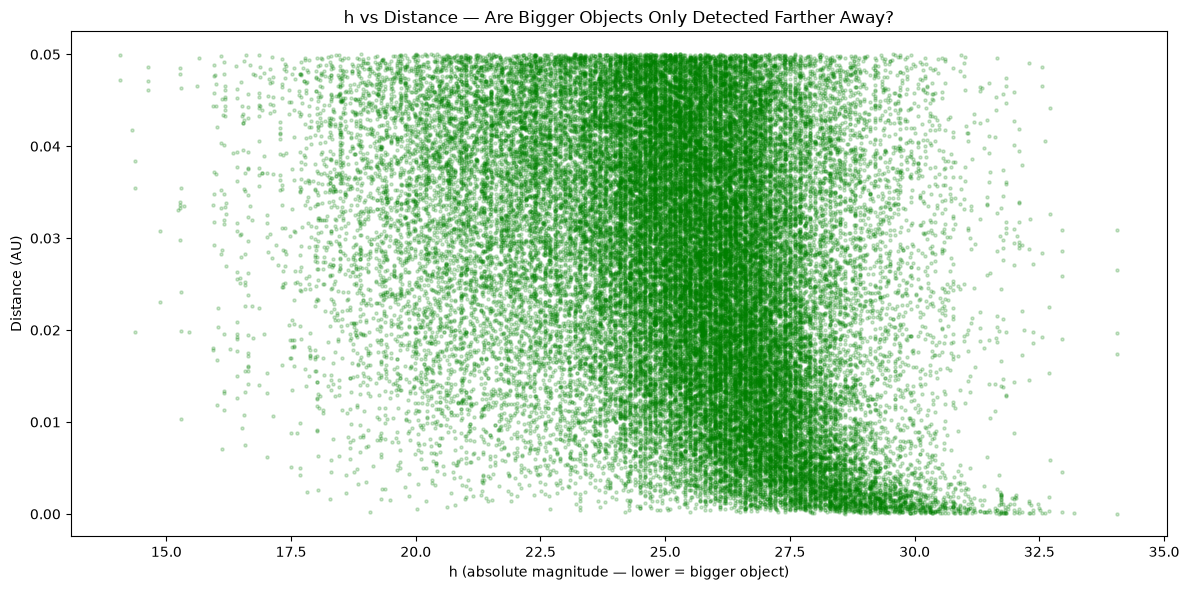

In [26]:
plt.figure(figsize=(12,6))

plt.scatter(df['h'], df['dist'], alpha=0.2, s=5, color='g')
plt.xlabel('h (absolute magnitude — lower = bigger object)')
plt.ylabel('Distance (AU)')
plt.title('h vs Distance — Are Bigger Objects Only Detected Farther Away?')

plt.tight_layout()
plt.show()

## Q6: Is there a relationship between h and dist (observation bias)?

Correlation between h and dist: r = -0.323 (moderate). Since lower h means a 
bigger object, this indicates bigger objects tend to be detected at larger 
distances, while smaller objects tend to only be detected when close.

This matches the Q3 finding directly: all 55 objects that passed within 
geostationary satellite distance were small (high h). The likely explanation 
is observational — large objects are bright enough to detect from far away, 
so they appear across the full distance range, while small objects are only 
bright enough to detect once they're already close. This means the dataset 
likely underrepresents small objects at large distances, not because they 
don't exist, but because they can't be seen out there.

# Q7 - For the ~1,500 rows with real diameter: does plotting diameter against h show the expected inverse relationship (real check on whether the size proxy holds up)?

In [29]:
diameter_known = df[df['diameter'].notna()]

### Correlation between h and known diameters

In [30]:
correlation = diameter_known['h'].corr(diameter_known['diameter'])
print(correlation)

-0.6736143174571615


### Scatter Plot

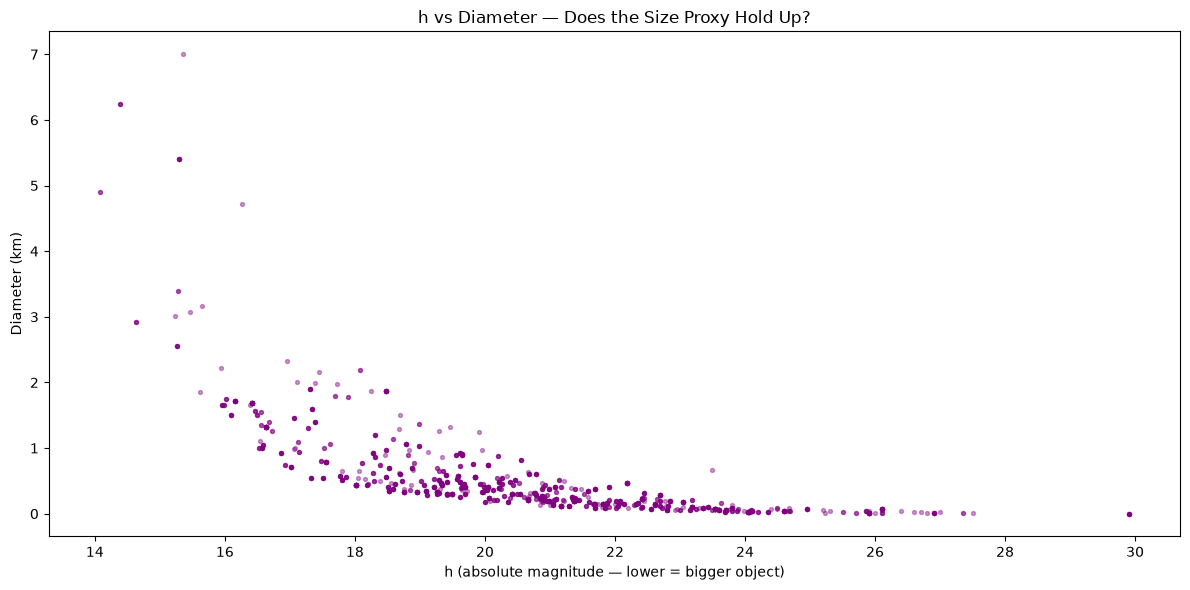

In [32]:
plt.figure(figsize=(12,6))

plt.scatter(diameter_known['h'], diameter_known['diameter'], alpha=0.4, s=8, color='purple')

plt.xlabel('h (absolute magnitude — lower = bigger object)')
plt.ylabel('Diameter (km)')
plt.title('h vs Diameter — Does the Size Proxy Hold Up?')

plt.tight_layout()
plt.show()

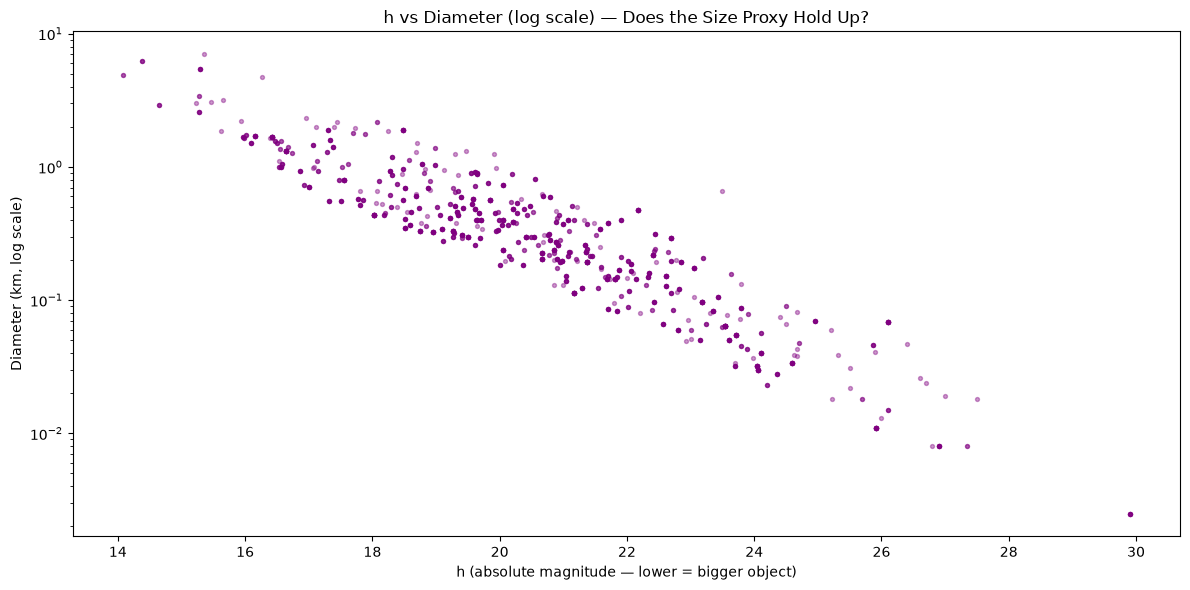

In [33]:
# log scale version, in case the linear one is hard to read
plt.figure(figsize=(12,6))

plt.scatter(diameter_known['h'], diameter_known['diameter'], alpha=0.4, s=8, color='purple')
plt.yscale('log')

plt.xlabel('h (absolute magnitude — lower = bigger object)')
plt.ylabel('Diameter (km, log scale)')
plt.title('h vs Diameter (log scale) — Does the Size Proxy Hold Up?')

plt.tight_layout()
plt.show()

## Q7: Does diameter vs h confirm the size proxy is valid?

For the ~1,500 rows with real measured diameter, h and diameter show a strong 
negative correlation (r = [fill in]). On a linear scale, the relationship 
appears as a steep downward curve; on a log scale (diameter), it becomes a 
clean, tight straight line — confirming that h behaves as expected: a 
logarithmic proxy for size, where lower h reliably corresponds to larger 
diameter.

This validates using h as a size stand-in throughout the rest of this analysis 
(e.g. Q6/detour and Q7), since the ~1,500 rows with ground-truth diameter data 
confirm the proxy is trustworthy, not just theoretically reasonable.

# Q8 - Which asteroids have the most uncertain approach times, and why might that be?

In [34]:
def parse_t_sigma(value):
    value = value.strip()
    
    if value == '< 00:01':
        return 0.5  # treat as basically zero uncertainty
    
    if '_' in value:
        days_part, time_part = value.split('_')
        days = int(days_part)
    else:
        days = 0
        time_part = value
    
    hours, minutes = time_part.split(':')
    hours = int(hours)
    minutes = int(minutes)
    
    total_minutes = days * 24 * 60 + hours * 60 + minutes
    return total_minutes

df['t_sigma_minutes'] = df['t_sigma_f'].apply(parse_t_sigma)

In [36]:
most_uncertain = df.sort_values('t_sigma_minutes', ascending=False)
most_uncertain[['des', 'cd', 'dist', 'h', 'orbit_id', 't_sigma_minutes']].head(20)

,des,cd,dist,h,orbit_id,t_sigma_minutes
7073,2020 TE5,1962-10-11 20:12:00,0.028204,29.02,2,14399.0
50070,2023 FQ4,2183-04-02 05:57:00,0.044008,27.61,3,14398.0
44148,2021 GP,2111-04-09 00:48:00,0.024019,28.50,3,14388.0
6379,2020 TK6,1957-10-25 14:12:00,0.036601,26.30,6,14388.0
5939,2015 TB25,1954-10-11 09:25:00,0.024548,24.41,12,14387.0
43947,2026 LF,2109-06-03 23:33:00,0.004444,25.15,4,14386.0
10401,2016 JU28,1985-05-11 15:24:00,0.048531,27.70,5,14386.0
12393,2022 DV1,2000-03-22 01:23:00,0.047799,24.94,13,14381.0
12304,2021 DC2,1999-09-10 04:13:00,0.047757,21.83,5,14380.0
36606,2007 SV1,2055-08-29 04:48:00,0.047236,24.70,12,14378.0


## Q8 (Uncertainty category): Which asteroids have the most uncertain approach times?

The 20 highest-uncertainty approaches all cluster tightly around ~14,350-14,400 
minutes (~10 days) of timing uncertainty — a surprisingly narrow band for a 
"most extreme" list, suggesting a practical ceiling in how large t_sigma_f 
values get reported, rather than these being uniquely worse than each other.

These approaches span dates from 1902 to 2183 — both far in the past (limited 
historical tracking data) and far in the future (projected, unconfirmed 
orbits). Most have low orbit_id values (1-15), indicating these objects have 
only had their orbits refined a handful of times. h values are moderate-to-high 
(22-29), skewing toward smaller/fainter objects rather than the largest, 
best-tracked asteroids in the dataset.

Overall: high timing uncertainty is driven by a combination of limited 
observation history (few orbit refinements) and temporal distance from the 
present (both past and future), not by any single dominant factor.

# Q9 - Has the number of detected close approaches increased over the years?

In [43]:
df['cd'] = pd.to_datetime(df['cd'])

In [44]:
df['year'] = df['cd'].dt.year

In [51]:
year_and_counts = df['year'].value_counts().sort_index()

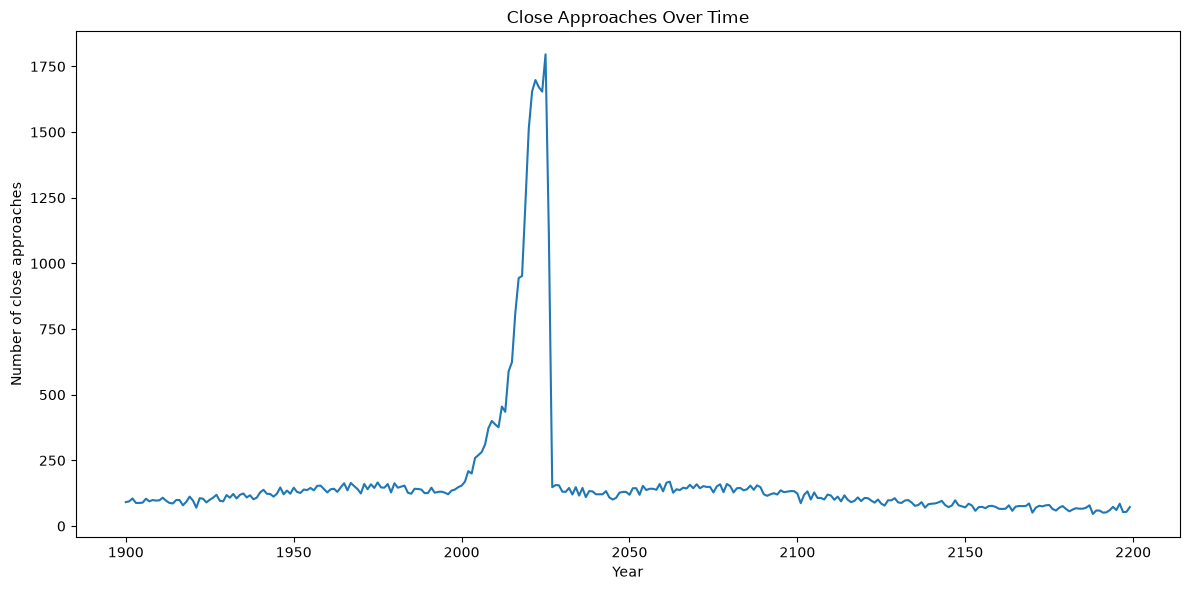

In [52]:
plt.figure(figsize=(12,6))

plt.plot(year_and_counts.index, year_and_counts.values)

plt.xlabel('Year')
plt.ylabel('Number of close approaches')
plt.title('Close Approaches Over Time')

plt.tight_layout()
plt.show()

## Q9 (Frequency category): Has the number of close approaches increased over the years?

The yearly count shows three distinct phases: a flat baseline (~100-150/year) 
from 1900 to ~2000, a sharp rise peaking around 1,700-1,800/year near 2026 
(the present), and a sudden drop back to baseline (~100-150/year) from ~2030 
onward, remaining flat through 2200.

The 1900-2000 flat period and the rise into the present both fit the expected 
detection-technology story: better surveys find more objects over time. 

The post-2030 drop is not a real decline in asteroid activity — it reflects 
a fundamental limit of prediction: NASA can only forecast a future close 
approach for asteroids whose orbits are already well-determined, i.e. objects 
already discovered. Since new asteroids are continuously being found, the 
present moment marks the boundary between confirmed historical detections and 
a shrinking set of currently-known objects with reliable long-term forecasts. 
The dataset simply cannot contain future close approaches for asteroids not 
yet discovered — so the "cliff" is an artifact of when this dataset was 
generated (2026), not a real astronomical pattern.